# Static Model Accuracy Over Time
This notebook trains a static RandomForest model on early months of credit data and evaluates accuracy on future months without retraining.

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [4]:
# Load the first 50,000 rows of the dataset
df = pd.read_csv('hc_processed.csv', nrows=50000)
df = df.sort_values('SIMULATED_MONTH')
# Convert 'SIMULATED_MONTH' to numeric, coercing errors to NaN
df['SIMULATED_MONTH'] = pd.to_numeric(df['SIMULATED_MONTH'], errors='coerce')
# Fill NaN values with a suitable replacement, e.g., -1
df['SIMULATED_MONTH'] = df['SIMULATED_MONTH'].fillna(-1).astype(int)
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AVG_PREV_AMT_APPLICATION,EARLIEST_DAYS_DECISION,NUM_PREV_APPLICATIONS,SIMULATED_MONTH
8028,109361,0,Cash loans,M,N,Y,0,135000.0,305221.5,15934.5,...,0,0,0,0,0,1,0.0,0,0,0
21874,125482,1,Cash loans,F,N,N,0,121500.0,1051294.5,29038.5,...,0,0,0,0,0,0,0.0,0,0,0
21878,125486,0,Cash loans,M,N,Y,0,126000.0,607500.0,16155.0,...,0,0,0,0,0,1,0.0,0,0,0
21845,125451,0,Cash loans,F,N,N,0,112500.0,316125.0,9711.0,...,0,0,0,0,0,0,0.0,0,0,0
17315,120194,1,Revolving loans,M,Y,Y,0,450000.0,1237500.0,61875.0,...,0,0,0,0,0,0,0.0,0,0,0


In [5]:
# Define features and target
features = [
    'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH',
    'AVG_PREV_AMT_APPLICATION', 'NUM_PREV_APPLICATIONS',
    'DAYS_EMPLOYED'
]
target = 'TARGET'

In [6]:
# Train a static model on first 3 months
min_month = df['SIMULATED_MONTH'].min()
max_month = df['SIMULATED_MONTH'].max()
train_months = list(range(min_month, min_month + 3))
train_data = df[df['SIMULATED_MONTH'].isin(train_months)]
X_train = train_data[features]
y_train = train_data[target]

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [7]:
# Evaluate on each month after the training window
results = []
for test_month in range(min_month + 3, max_month + 1):
    test_data = df[df['SIMULATED_MONTH'] == test_month]
    if test_data.empty:
        continue
    X_test = test_data[features]
    y_test = test_data[target]
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({'Test Month': test_month, 'Accuracy': acc})

results_df = pd.DataFrame(results)
results_df.head()

,Test Month,Accuracy
0,3,0.933333
1,4,0.921429
2,5,0.894558
3,6,0.891803
4,7,0.913947


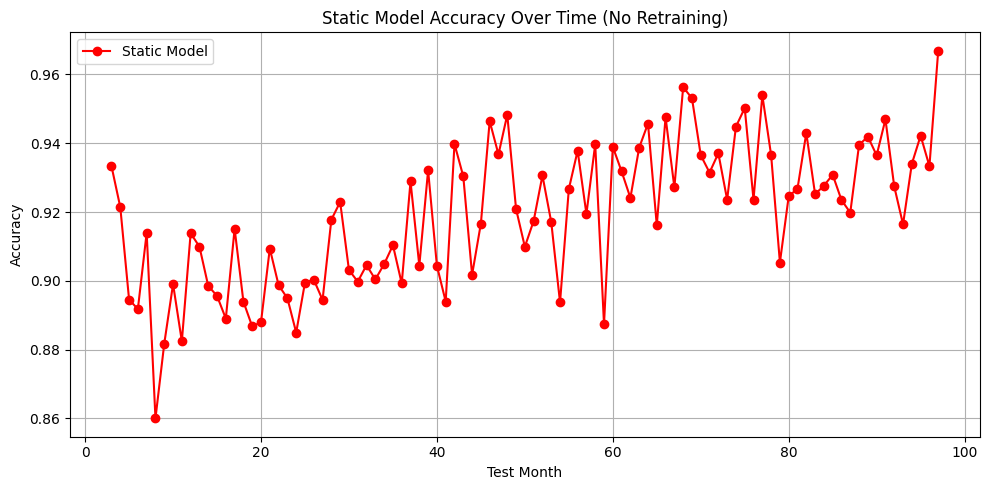

In [8]:
# Plot accuracy over time
plt.figure(figsize=(10, 5))
plt.plot(results_df['Test Month'], results_df['Accuracy'], marker='o', color='red', label='Static Model')
plt.title('Static Model Accuracy Over Time (No Retraining)')
plt.xlabel('Test Month')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()